# Loss Reserving with Chain-Ladder: Triangle Diagnostics, Bootstrap Uncertainty, and Governance

**The problem.** An insurer's balance sheet depends on a single number the market does not let it see: the eventual cost of claims already incurred but not yet fully paid — IBNR. Under-reserve and the firm is insolvent before it knows. Over-reserve and capital is trapped in the balance sheet where it earns nothing. The question this notebook answers: **given an observed paid triangle, what is the central IBNR estimate, what is the uncertainty around it, and what risk margin should a reserving committee book?**

**The approach.** On a realistic synthetic cumulative paid triangle (12 accident years × 12 development periods):

1. Diagnostics on the raw triangle — monotonicity, missingness, shape.
2. Deterministic **chain-ladder** projection via volume-weighted age-to-age factors.
3. IBNR concentration and maturity analysis — where reserve risk sits.
4. **Bootstrap resampling** of link ratios to build an empirical IBNR distribution.
5. Risk-margin interpretation (P75, P95) and a committee-ready governance table.

**Audience.** Reserving actuaries, reserve committee reviewers, and finance/risk partners translating technical reserving outputs into capital decisions.

## 0. Setup and reproducibility

All randomness is seeded so triangles, link factors, bootstrap percentiles, and governance numbers are identical across runs.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(11)
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

C:\Users\diogo\AppData\Roaming\Python\Python312\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\diogo\AppData\Roaming\Python\Python312\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


## 1. Building a synthetic cumulative paid triangle

We generate a triangle that mirrors the typical shape reviewers expect: a mild inflation trend across accident years, a realistic S-shaped development pattern to ultimate, light diagonal (calendar) effects, and modest noise. Using synthetic data keeps the notebook runnable anywhere while exercising the same diagnostics, projection, and bootstrap logic a production workflow would apply to real claims data.

In [2]:
accident_years = np.arange(2014, 2026)  # 12 AYs
dev_periods = np.arange(1, 13)          # 12 dev periods

# AY-level ultimate severity with mild trend
base_ult = np.random.lognormal(mean=10.6, sigma=0.22, size=len(accident_years))
inflation_trend = np.linspace(0.92, 1.08, len(accident_years))
ultimates = base_ult * inflation_trend

# CDF pattern to ultimate
cdf_pattern = np.array([0.18, 0.33, 0.47, 0.60, 0.70, 0.78, 0.84, 0.89, 0.93, 0.96, 0.985, 1.00])

triangle = pd.DataFrame(index=accident_years, columns=dev_periods, dtype=float)
for i, ay in enumerate(accident_years):
    max_dev_observed = len(accident_years) - i
    for d in dev_periods[:max_dev_observed]:
        noise = np.random.normal(1.0, 0.025)
        cal_effect = 1.0 + 0.01 * np.sin((ay + d) / 3.5)
        triangle.loc[ay, d] = ultimates[i] * cdf_pattern[d - 1] * noise * cal_effect

# enforce cumulative monotonicity
triangle = triangle.cummax(axis=1)
triangle.round(0).head()

,1,2,3,4,5,6,7,8,9,10,11,12
2014,9863.0,17995.0,24427.0,31328.0,38320.0,43640.0,45275.0,47306.0,51814.0,51814.0,54683.0,56765.0
2015,6382.0,11530.0,16689.0,20599.0,24350.0,26919.0,29336.0,30948.0,32678.0,33655.0,35019.0,NaN
2016,6112.0,11269.0,16502.0,19593.0,24600.0,26460.0,27861.0,30412.0,32074.0,33991.0,NaN,NaN
2017,3743.0,7091.0,10089.0,12327.0,14605.0,17071.0,18480.0,19820.0,20478.0,NaN,NaN,NaN
2018,7057.0,12869.0,18864.0,22941.0,27320.0,30932.0,31776.0,36279.0,NaN,NaN,NaN,NaN


## 2. Triangle diagnostics

Before projecting, we check the structural properties the chain-ladder assumes: **cumulative monotonicity** (each development period ≥ the last — no negative development allowed in the data structure), **complete observed cells**, and a visible development pattern in the heatmap. A broken triangle silently breaks every downstream link factor; diagnostics first.

In [3]:
# Monotonicity and missingness checks
violations = 0
for ay in triangle.index:
    row = triangle.loc[ay].dropna().to_numpy()
    if np.any(np.diff(row) < 0):
        violations += 1

missing_cells = int(triangle.isna().sum().sum())

diag = pd.Series(
    {
        "num_accident_years": len(triangle),
        "num_dev_periods": triangle.shape[1],
        "missing_cells": missing_cells,
        "monotonicity_violations": violations,
        "latest_diagonal_paid": sum(triangle.loc[ay, len(accident_years) - i] for i, ay in enumerate(accident_years)),
    }
)
diag

num_accident_years             12.000000
num_dev_periods                12.000000
missing_cells                  66.000000
monotonicity_violations         0.000000
latest_diagonal_paid       334741.050686
dtype: float64

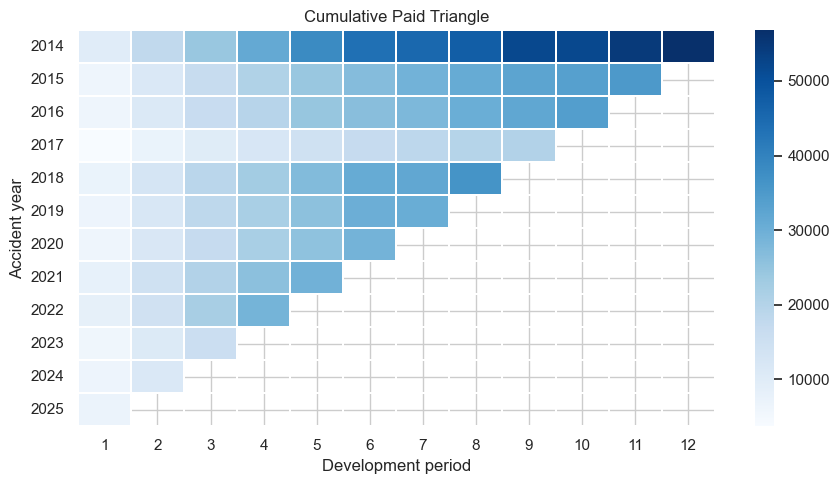

In [4]:
plt.figure(figsize=(9, 5))
sns.heatmap(triangle, cmap="Blues", linewidths=0.2, linecolor="white")
plt.title("Cumulative Paid Triangle")
plt.xlabel("Development period")
plt.ylabel("Accident year")
plt.tight_layout()
plt.show()

**What to read here.** The upper-triangular shape of the heatmap is the observed data; the lower-right white region is what we need to project. Horizontal bands should show steadily darker (higher cumulative paid) values across development periods — that is the cumulative pattern. Vertical bands reflecting the AY-over-AY inflation trend should also be visible. Zero monotonicity violations and zero missing cells (above) confirm the triangle is structurally clean before we fit anything.

## 3. Chain-ladder age-to-age factors

The **age-to-age factor** for development period *d* is the volume-weighted ratio of cumulative paid at *d+1* to *d*, across all accident years that observe both. Chain-ladder's core assumption: these ratios are stable enough to be applied to accident years that haven't yet reached *d+1*. The cumulative product of remaining factors gives the **CDF-to-ultimate** — the multiplier that takes latest-paid to projected ultimate.

In [5]:
link_factors = {}
for d in range(1, triangle.shape[1]):
    num = 0.0
    den = 0.0
    for ay in accident_years:
        if pd.notna(triangle.loc[ay, d]) and pd.notna(triangle.loc[ay, d + 1]):
            num += triangle.loc[ay, d + 1]
            den += triangle.loc[ay, d]
    link_factors[d] = num / den

f = pd.Series(link_factors, name="age_to_age")

# cumulative development factors to ultimate
cdf_to_ult = {triangle.shape[1]: 1.0}
prod = 1.0
for d in range(triangle.shape[1] - 1, 0, -1):
    prod *= f[d]
    cdf_to_ult[d] = prod

cdf = pd.Series(cdf_to_ult).sort_index()
cdf.name = "cdf_to_ultimate"

factor_table = pd.DataFrame(
    {
        "dev_period": np.arange(1, triangle.shape[1]),
        "age_to_age": [f[d] for d in range(1, triangle.shape[1])],
        "cdf_to_ultimate": [cdf[d] for d in range(1, triangle.shape[1])],
    }
)
factor_table

,dev_period,age_to_age,cdf_to_ultimate
0,1,1.822228,5.941265
1,2,1.441064,3.260441
2,3,1.249763,2.262523
3,4,1.189012,1.810362
4,5,1.133193,1.522577
5,6,1.045810,1.343617
6,7,1.078832,1.284762
7,8,1.066596,1.190882
8,9,1.024828,1.116525
9,10,1.049522,1.089476


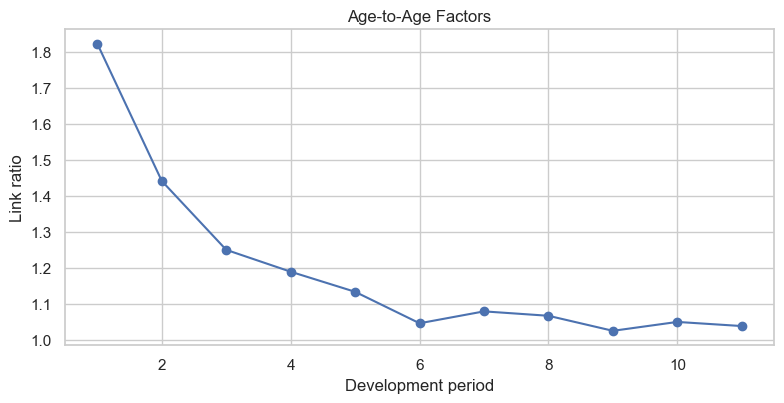

In [6]:
plt.figure(figsize=(8, 4.2))
plt.plot(factor_table["dev_period"], factor_table["age_to_age"], marker="o", color="#4C72B0")
plt.title("Age-to-Age Factors")
plt.xlabel("Development period")
plt.ylabel("Link ratio")
plt.tight_layout()
plt.show()

**What to read here.** A well-behaved age-to-age curve decreases smoothly toward 1.0 as development matures — early periods pay out a lot relative to cumulative paid, late periods barely move. Jagged or non-monotonic factors are a red flag: either the tail is noisy (few AYs inform those columns — a **volume** problem) or there is a genuine calendar/structural break that chain-ladder won't capture without an adjustment (e.g. a Bornhuetter-Ferguson blend).

## 4. Deterministic ultimates and IBNR

For each accident year, projected ultimate = latest paid × CDF-to-ultimate at its latest observed development period. IBNR is simply ultimate minus latest paid — the portion we expect still to pay but haven't. Totals roll up to portfolio IBNR and IBNR / latest paid, the first number any reserving committee wants to see.

In [7]:
rows = []
for i, ay in enumerate(accident_years):
    latest_dev = len(accident_years) - i
    latest_paid = triangle.loc[ay, latest_dev]
    selected_cdf = cdf.loc[latest_dev]

    ultimate = latest_paid * selected_cdf
    ibnr = ultimate - latest_paid

    rows.append(
        {
            "accident_year": ay,
            "latest_dev": latest_dev,
            "latest_paid": latest_paid,
            "selected_cdf": selected_cdf,
            "projected_ultimate": ultimate,
            "ibnr": ibnr,
        }
    )

cl = pd.DataFrame(rows)
cl

,accident_year,latest_dev,latest_paid,selected_cdf,projected_ultimate,ibnr
0,2014,12,56764.725110,1.000000,56764.725110,0.000000
1,2015,11,35019.260106,1.038069,36352.395470,1333.135363
2,2016,10,33990.563708,1.089476,37031.891839,3041.328131
3,2017,9,20477.693389,1.116525,22863.858364,2386.164976
4,2018,8,36279.497533,1.190882,43204.591191,6925.093658
5,2019,7,30571.651920,1.284762,39277.283876,8705.631956
6,2020,6,29172.565010,1.343617,39196.740194,10024.175185
7,2021,5,29513.133986,1.522577,44936.009181,15422.875194
8,2022,4,28848.847175,1.810362,52226.854666,23378.007491
9,2023,3,15605.828876,2.262523,35308.549972,19702.721096


In [8]:
total_latest_paid = cl["latest_paid"].sum()
total_ultimate = cl["projected_ultimate"].sum()
total_ibnr = cl["ibnr"].sum()

summary = pd.Series(
    {
        "total_latest_paid": total_latest_paid,
        "total_projected_ultimate": total_ultimate,
        "total_ibnr": total_ibnr,
        "ibnr_to_latest_paid_ratio": total_ibnr / total_latest_paid,
    }
)
summary

total_latest_paid            334741.050686
total_projected_ultimate     486383.834906
total_ibnr                   151642.784221
ibnr_to_latest_paid_ratio         0.453015
dtype: float64

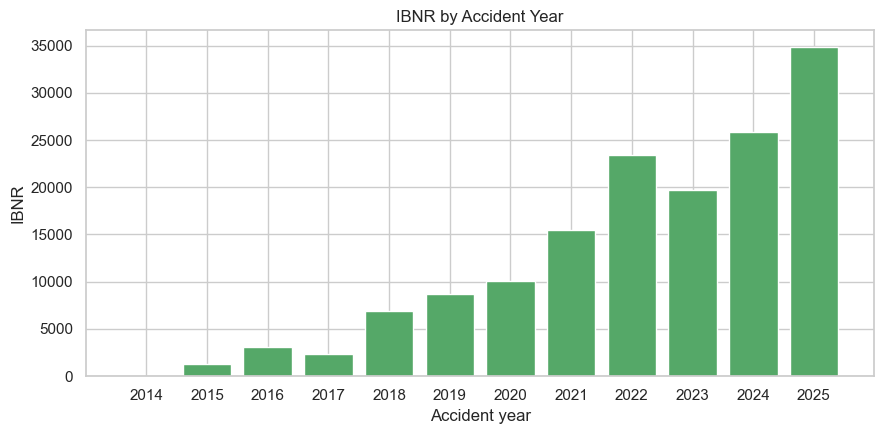

In [9]:
plt.figure(figsize=(9, 4.5))
plt.bar(cl["accident_year"].astype(str), cl["ibnr"], color="#55A868")
plt.title("IBNR by Accident Year")
plt.xlabel("Accident year")
plt.ylabel("IBNR")
plt.tight_layout()
plt.show()

**What to read here.** IBNR concentrates in the *youngest* accident years — those with the most development periods still to run. Older (more mature) AYs have largely paid out and contribute little. If this notebook showed material IBNR on mature AYs, that would indicate stale tail behaviour and warrant a tail-factor adjustment beyond chain-ladder.

## 5. Reserve concentration and maturity

Headline IBNR hides structure. Two questions a reviewer will ask: **how concentrated** is IBNR in a few accident years (large single-AY shares signal reserve sensitivity to that year's development), and **how mature** are the AYs carrying the most IBNR (early-maturity bucketed reserves are much more uncertain than late-maturity ones). The maturity bucket table below drives the risk margin case that follows.

In [10]:
cl["ibnr_share"] = cl["ibnr"] / cl["ibnr"].sum()
cl["maturity_bucket"] = pd.cut(
    cl["latest_dev"],
    bins=[0, 3, 6, 9, 12],
    labels=["early(1-3)", "mid(4-6)", "late(7-9)", "mature(10-12)"],
)

maturity = (
    cl.groupby("maturity_bucket", as_index=False, observed=False)
    .agg(total_ibnr=("ibnr", "sum"), ay_count=("accident_year", "size"))
)
maturity["share"] = maturity["total_ibnr"] / maturity["total_ibnr"].sum()

cl.sort_values("ibnr", ascending=False).head(6), maturity

(    accident_year  latest_dev   latest_paid  selected_cdf  projected_ultimate  \
 11           2025           1   7054.412512      5.941265        41912.132028   
 10           2024           2  11442.871360      3.260441        37308.803015   
 8            2022           4  28848.847175      1.810362        52226.854666   
 9            2023           3  15605.828876      2.262523        35308.549972   
 7            2021           5  29513.133986      1.522577        44936.009181   
 6            2020           6  29172.565010      1.343617        39196.740194   
 
             ibnr  ibnr_share maturity_bucket  
 11  34857.719515    0.229867      early(1-3)  
 10  25865.931655    0.170571      early(1-3)  
 8   23378.007491    0.154165        mid(4-6)  
 9   19702.721096    0.129929      early(1-3)  
 7   15422.875194    0.101705        mid(4-6)  
 6   10024.175185    0.066104        mid(4-6)  ,
   maturity_bucket    total_ibnr  ay_count     share
 0      early(1-3)  80426.372266  

## 6. Bootstrap uncertainty (link-ratio resampling)

Deterministic chain-ladder gives a point estimate. A reserve committee needs a **distribution** — without one, there is no basis for a risk margin. We bootstrap by resampling observed age-to-age ratios (with a small multiplicative jitter to inject estimation noise), recomputing a CDF and IBNR on each draw, and repeating 1,500 times. The resulting empirical IBNR distribution is the raw material for every governance percentile that follows.

In [11]:
# Collect empirical link-ratio pools by development period
ratio_pool = {}
for d in range(1, triangle.shape[1]):
    ratio_pool[d] = np.array(
        [
            triangle.loc[ay, d + 1] / triangle.loc[ay, d]
            for ay in accident_years
            if pd.notna(triangle.loc[ay, d]) and pd.notna(triangle.loc[ay, d + 1])
        ]
    )

n_boot = 1500
boot_totals = []

for _ in range(n_boot):
    # bootstrap factors
    bf = {}
    for d in range(1, triangle.shape[1]):
        draws = np.random.choice(ratio_pool[d], size=max(len(ratio_pool[d]), 20), replace=True)
        bf[d] = np.mean(draws) * np.random.normal(1.0, 0.01)

    # convert to CDF
    bcdf = {triangle.shape[1]: 1.0}
    prod = 1.0
    for d in range(triangle.shape[1] - 1, 0, -1):
        prod *= bf[d]
        bcdf[d] = prod

    total_ibnr_boot = 0.0
    for i, ay in enumerate(accident_years):
        latest_dev = len(accident_years) - i
        latest_paid = triangle.loc[ay, latest_dev]
        total_ibnr_boot += latest_paid * bcdf[latest_dev] - latest_paid

    boot_totals.append(total_ibnr_boot)

boot_totals = np.array(boot_totals)

boot_stats = pd.Series(
    {
        "mean": float(np.mean(boot_totals)),
        "std": float(np.std(boot_totals, ddof=1)),
        "p50": float(np.quantile(boot_totals, 0.50)),
        "p75": float(np.quantile(boot_totals, 0.75)),
        "p90": float(np.quantile(boot_totals, 0.90)),
        "p95": float(np.quantile(boot_totals, 0.95)),
        "p99": float(np.quantile(boot_totals, 0.99)),
    }
)
boot_stats

mean    152186.978528
std       9978.175572
p50     152219.493041
p75     158762.174637
p90     165117.752453
p95     169280.086227
p99     174637.130969
dtype: float64

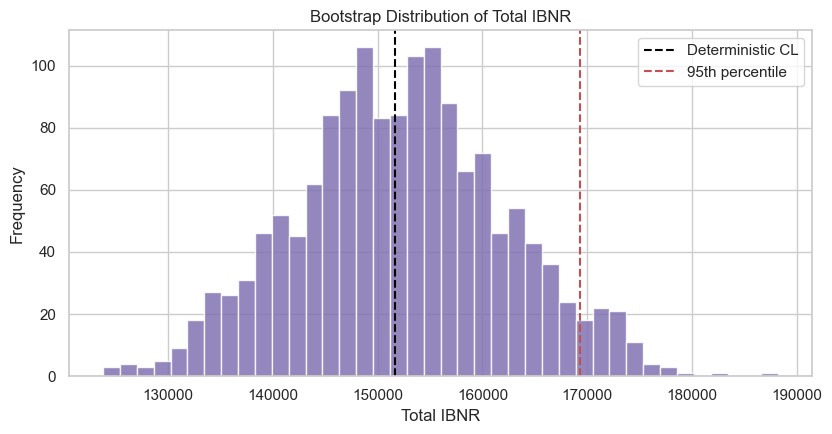

In [12]:
plt.figure(figsize=(8.5, 4.5))
plt.hist(boot_totals, bins=40, color="#8172B2", alpha=0.85)
plt.axvline(total_ibnr, color="black", linestyle="--", label="Deterministic CL")
plt.axvline(np.quantile(boot_totals, 0.95), color="#C44E52", linestyle="--", label="95th percentile")
plt.title("Bootstrap Distribution of Total IBNR")
plt.xlabel("Total IBNR")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

**What to read here.** The black dashed line is the deterministic chain-ladder estimate — it should sit close to the bootstrap mean/median. The red dashed line is the 95th percentile — the "stressed reserve" a committee might book in an adverse scenario. The *gap* between the two is the reserve uncertainty the bootstrap is quantifying; a wide gap means the book is sensitive to link-ratio assumptions and justifies a larger risk margin.

## 7. Risk margin and reserve adequacy lens

A **risk margin** converts reserve uncertainty into a capital amount held above the central estimate. Regulators and rating agencies typically anchor it at a percentile (Solvency II uses cost-of-capital on VaR-99.5; IFRS 17 uses a confidence-level disclosure). We present P75 as a working margin and P95 as a stress buffer; the coefficient of variation is the portable, scale-free summary of reserve volatility.

In [13]:
risk_margin = np.quantile(boot_totals, 0.75) - total_ibnr
reserve_with_margin = total_ibnr + risk_margin

adequacy = pd.Series(
    {
        "deterministic_ibnr": total_ibnr,
        "risk_margin_p75_minus_mean": risk_margin,
        "reserve_including_margin": reserve_with_margin,
        "p95_minus_mean_stress_buffer": np.quantile(boot_totals, 0.95) - total_ibnr,
        "coefficient_of_variation": np.std(boot_totals, ddof=1) / np.mean(boot_totals),
    }
)
adequacy

deterministic_ibnr              151642.784221
risk_margin_p75_minus_mean        7119.390416
reserve_including_margin        158762.174637
p95_minus_mean_stress_buffer     17637.302007
coefficient_of_variation             0.065565
dtype: float64

## 8. Governance summary

One table, everything a reserve committee needs to read before voting: the central estimate, the uncertainty around it, the percentile-based buffers, the concentration risk, and the IBNR / paid ratio as a coverage indicator. This is the one-pager that should close any reserving pack.

In [14]:
governance = pd.DataFrame(
    {
        "metric": [
            "Deterministic IBNR",
            "Bootstrap mean IBNR",
            "Bootstrap std",
            "P75 IBNR",
            "P95 IBNR",
            "Largest AY IBNR share",
            "Top-3 AY IBNR share",
            "IBNR / Latest Paid",
        ],
        "value": [
            total_ibnr,
            np.mean(boot_totals),
            np.std(boot_totals, ddof=1),
            np.quantile(boot_totals, 0.75),
            np.quantile(boot_totals, 0.95),
            cl["ibnr_share"].max(),
            cl["ibnr_share"].sort_values(ascending=False).head(3).sum(),
            total_ibnr / total_latest_paid,
        ],
    }
)
governance

,metric,value
0,Deterministic IBNR,151642.784221
1,Bootstrap mean IBNR,152186.978528
2,Bootstrap std,9978.175572
3,P75 IBNR,158762.174637
4,P95 IBNR,169280.086227
5,Largest AY IBNR share,0.229867
6,Top-3 AY IBNR share,0.554604
7,IBNR / Latest Paid,0.453015


## 9. Takeaways, limitations, and what a production version would add

**Takeaways**

- Deterministic chain-ladder gives a defensible central IBNR estimate when the triangle is structurally clean (monotone, complete, well-behaved link factors).
- The reserve committee should *not* book the deterministic number as-is. A risk margin anchored at P75 or P95 of the bootstrap distribution is the minimum expected of any modern reserving pack.
- IBNR concentration matters as much as headline volume: reserve volatility is driven disproportionately by young, immature accident years, and the governance summary should expose that.
- Bootstrap uncertainty without a clean triangle is a false precision — diagnostics first, projection second, distribution third.

**Limitations**

- A single cumulative paid triangle ignores incurred-but-not-reported nuance, reopened claims, and large-loss separation. Production reserving usually blends paid, incurred, and counts triangles.
- Chain-ladder assumes stable calendar-year development. Material inflation shifts, legal regime changes, or COVID-style one-offs require explicit adjustments (e.g. calendar-year factors, Bornhuetter-Ferguson).
- Link-ratio bootstrap captures parameter uncertainty but not model uncertainty — the choice of chain-ladder itself is not being bootstrapped against alternatives.

**What a production version would add**

- **Mack's analytical standard error** alongside the bootstrap for a cross-check.
- **Bornhuetter-Ferguson and Cape Cod** blends where chain-ladder is known to be unstable at the tail.
- **Large-loss isolation** and explicit tail factor selection with supporting industry benchmarks.
- **Back-testing** against historical ultimates so the bootstrap distribution can be calibrated rather than merely reported.